This will be the improved version of the ck_gad.ipynb file. I want to write the code more carefully with comments now that I have a proof of concept and wish to integrate CK descent steps and tools to compare performance of the neural net after tasks like that. 

I'm going to switch to a different dataset to get some variety.

In [119]:
# imports
import torch
print(torch.__version__)
import torchvision
import torchvision.datasets as datasets
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt


2.12.1


In [27]:
transform = transforms.ToTensor()
mnist_trainset = datasets.MNIST(root='./mnist_data', train=True, download=True, transform=transform)
mnist_testset = datasets.MNIST(root='./mnist_data', train=False, download=True, transform=transform)


In [28]:
train_loader = DataLoader(mnist_trainset, batch_size=128, shuffle=True)
test_loader = DataLoader(mnist_testset, batch_size=128, shuffle=True)

In [56]:
class MLP(nn.Module):
    def __init__(self, width):
        super().__init__()
        # turn square pictures into flat vectors 
        self.flatten = nn.Flatten()
        # 784 is the number of pixels and the width of the hidden layer is going to vary
        self.hidden = nn.Linear(784, width)
        # using basic ReLU() which is just max(0, z)
        self.relu = nn.ReLU()
        # 10 is the number of digits / categories so that's how many outputs we will have
        self.output = nn.Linear(width, 10)

    def forward(self, x):
        # turn these into long vectors of pixels
        x = self.flatten(x) 
        # multiply by W_1 matrix and add biases
        z = self.hidden(x)
        # apply the activation functions
        features = self.relu(z)        
        # multiply by W_2 matrix and add biases
        logits = self.output(features)
        # these will be logits
        return features, logits

In [30]:
model = MLP(width=500)

In [ ]:
new_model = MLP(width=500)
new_model.load_state_dict(model.state_dict())

<All keys matched successfully>

In [64]:
model = new_model

In [66]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [65]:
def train_epoch(return_features=False):
    # put the model in train mode
    model.train()
    # used to track loss so you can see if the training is working
    total_loss = 0
    epoch_features = []
    
    # mini-batch SGD
    for x, y in train_loader:
        optimizer.zero_grad()
        features, logits = model(x)
        epoch_features.append(features)
        loss = criterion(logits, y)
        # compute the gradient and store it in .grad attributes of each of the model parameters
        loss.backward()
        # optimizer can access attributes of model parameters and update the parameters
        optimizer.step()
        total_loss += loss.item()
    if return_features:
        return epoch_features, total_loss / len(train_loader)
    return total_loss / len(train_loader)

Notes to self: to think about the interpolation threshold I'd like to plot SVD spectrum of the W_1 matrix because the tiny values are mostly noise and the large ones are meaningful directions. Also I could try to plot effective rank, which measures how many directions actually matter. These could be my x axis to observe double descent / interpolation threshold?

In [60]:
# evaluate the model's accuracy 
def evaluate_acc(model, loader):
    # put the model in test mode
    model.eval()
    
    correct = 0
    total = 0

    with torch.no_grad():

        for x,y in loader:
            # this calls forward with some wrappers that make it work better i guess
            _, logits = model(x)
            # model predicts the largest value to be the digit
            pred = logits.argmax(dim=1)
            # item makes it a number 
            correct += (pred == y).sum().item()
            total += y.size(0)

    return correct / total

In [67]:
optimizer.param_groups[0]['momentum'] = 0.9
for param_group in optimizer.param_groups:
    param_group['lr'] = 0.05

In [61]:
losses = []
train_accs = []
test_accs = []
all_epochs_features = []

In [88]:
for epoch in range(10):
    train_acc = evaluate_acc(model, train_loader)
    test_acc = evaluate_acc(model, test_loader)

    # loss = train_epoch()

    epoch_features, loss = train_epoch(return_features=True)
    all_epochs_features.append(epoch_features)

    losses.append(loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    print(
        epoch,
        loss,
        train_acc,
        test_acc
    )

0 0.0006212469037765684 1.0 0.9825
1 0.0006075348837044476 1.0 0.9825
2 0.0005947948916371404 1.0 0.9827
3 0.0005790290226969348 1.0 0.9822
4 0.0005676136006164783 1.0 0.9823
5 0.0005562666595155405 1.0 0.9825
6 0.000542645165248082 1.0 0.9826
7 0.0005317326262605681 1.0 0.9828
8 0.0005202479217437777 1.0 0.9825
9 0.0005114848122725746 1.0 0.9826


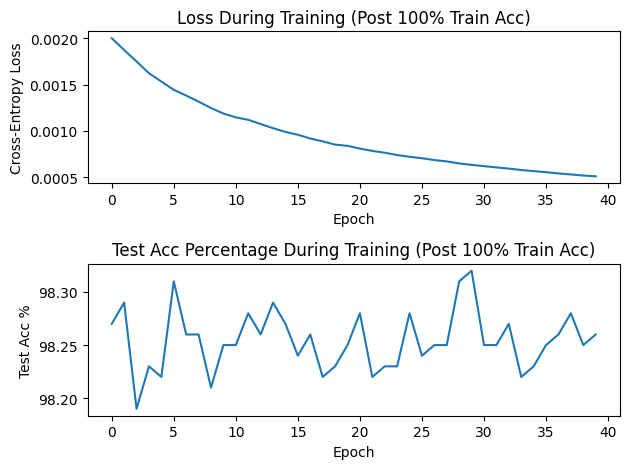

In [89]:
plt.subplot(211)
plt.title("Loss During Training (Post 100% Train Acc)")
plt.xlabel("Epoch")
plt.xticks(range(0, len(losses) + 1, 5))
plt.ylabel("Cross-Entropy Loss")
plt.plot(losses)
plt.subplot(212)
plt.title("Test Acc Percentage During Training (Post 100% Train Acc)")
plt.xlabel("Epoch")
plt.xticks(range(0, len(test_accs) + 1, 5))
plt.ylabel("Test Acc %")
plt.plot(np.array(test_accs)*100)
plt.tight_layout()
plt.show()

In [90]:
big_matrices = [torch.cat(epoch_list, dim=0) for epoch_list in all_epochs_features]

In [ ]:
# save features and logits before conjugate kernel regression
with torch.no_grad():
    # TEST
    test_features_list = []
    test_logits_original = []
    test_targets_list = []

    for x,y in test_loader:
        features, logits = model(x)
        test_features_list.append(features.cpu())
        test_logits_original.append(logits.cpu())
        test_targets_list.append(y.cpu())
    
    Phi_test = torch.cat(test_features_list, dim=0)
    test_logits_original = torch.cat(test_logits_original, dim=0)
    test_targets = torch.cat(test_targets_list, dim=0)

    # TRAIN
    train_features_list = []
    train_logits_original = []
    train_targets_list = []

    for x, y in train_loader:
        features, logits = model(x)
        train_features_list.append(features.cpu())
        train_logits_original.append(logits.cpu())
        train_targets_list.append(y.cpu())

    Phi_train = torch.cat(train_features_list, dim=0)
    train_logits_original = torch.cat(train_logits_original, dim=0)
    train_targets = torch.cat(train_targets_list, dim=0)


In [109]:
Y_test_onehot = torch.nn.functional.one_hot(test_targets, 10).float()
Y_train_onehot = torch.nn.functional.one_hot(train_targets, 10).float()
W2_ls = torch.linalg.pinv(Phi_train) @ Y_train_onehot
test_logits_ls = Phi_test @ W2_ls
train_logits_ls = Phi_train @ W2_ls

In [104]:
def get_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item() * 100

print(f"Original network test accuracy: {get_accuracy(test_logits_original, test_targets):.2f}%")
print(f"Least-squares W2 (no bias, no regularization) test accuracy: {get_accuracy(test_logits_ls, test_targets):.2f}%")

Original network test accuracy: 98.23%
Least-squares W2 (no bias, no regularization) test accuracy: 97.02%


In [107]:
print(f"Original network train accuracy: {get_accuracy(train_logits_original, train_targets):.2f}%")
print(f"Least-squares W2 (no bias, no regularization) train accuracy: {get_accuracy(train_logits_ls, train_targets):.2f}%")

Original network train accuracy: 100.00%
Least-squares W2 (no bias, no regularization) train accuracy: 98.04%


In [111]:
def get_mse(logits, onehot_targets):
    return ((logits - onehot_targets)**2).mean().item()

print(f"Original network test MSE: {get_mse(test_logits_original, Y_test_onehot)}")
print(f"Least-squares W2 (no bias, no regularization) test MSE: {get_mse(test_logits_ls, Y_test_onehot)}")

Original network test MSE: 124.6888198852539
Least-squares W2 (no bias, no regularization) test MSE: 0.016929570585489273


In [113]:
print(f"Original network train MSE: {get_mse(train_logits_original, Y_train_onehot)}")
print(f"Least-squares W2 (no bias, no regularization) train MSE: {get_mse(train_logits_ls, Y_train_onehot)}")

Original network train MSE: 121.04488372802734
Least-squares W2 (no bias, no regularization) train MSE: 0.016412559896707535


In [ ]:
ones_train = torch.ones(Phi_train.shape[0], 1)
ones_test = torch.ones(Phi_test.shape[0], 1)

Phi_train_bias = torch.cat([Phi_train, ones_train], dim=1)
Phi_test_bias = torch.cat([Phi_test, ones_test], dim=1)

W2_ls_bias = torch.linalg.pinv(Phi_train_bias) @ Y_train_onehot
test_logits_ls_bias = Phi_test_bias @ W2_ls_bias
train_logits_ls_bias = Phi_train_bias @ W2_ls_bias

In [117]:
print(f"Original network test accuracy: {get_accuracy(test_logits_original, test_targets):.2f}%")
print(f"Least-squares W2 (with bias, no regularization) test accuracy: {get_accuracy(test_logits_ls_bias, test_targets):.2f}%")
print(f"Original network train accuracy: {get_accuracy(train_logits_original, train_targets):.2f}%")
print(f"Least-squares W2 (with bias, no regularization) train accuracy: {get_accuracy(train_logits_ls_bias, train_targets):.2f}%")
print(f"Original network test MSE: {get_mse(test_logits_original, Y_test_onehot)}")
print(f"Least-squares W2 (with bias, no regularization) test MSE: {get_mse(test_logits_ls_bias, Y_test_onehot)}")
print(f"Original network train MSE: {get_mse(train_logits_original, Y_train_onehot)}")
print(f"Least-squares W2 (with bias, no regularization) train MSE: {get_mse(train_logits_ls_bias, Y_train_onehot)}")

Original network test accuracy: 98.23%
Least-squares W2 (with bias, no regularization) test accuracy: 97.03%
Original network train accuracy: 100.00%
Least-squares W2 (with bias, no regularization) train accuracy: 98.05%
Original network test MSE: 124.6888198852539
Least-squares W2 (with bias, no regularization) test MSE: 0.016867320984601974
Original network train MSE: 121.04488372802734
Least-squares W2 (with bias, no regularization) train MSE: 0.016350172460079193


In [162]:
lam = 100
W2_ls_reg = torch.linalg.solve(
    Phi_train.T @ Phi_train + lam * torch.eye(Phi_train.shape[1]),
    Phi_train.T @ Y_train_onehot
)
test_logits_ls_reg = Phi_test @ W2_ls_reg
train_logits_ls_reg = Phi_train @ W2_ls_reg

In [163]:
print(f"Original network test accuracy: {get_accuracy(test_logits_original, test_targets):.2f}%")
print(f"Least-squares W2 (no bias, with regularization) test accuracy: {get_accuracy(test_logits_ls_reg, test_targets):.2f}%")
print(f"Original network train accuracy: {get_accuracy(train_logits_original, train_targets):.2f}%")
print(f"Least-squares W2 (no bias, with regularization) train accuracy: {get_accuracy(train_logits_ls_reg, train_targets):.2f}%")
print(f"Original network test MSE: {get_mse(test_logits_original, Y_test_onehot)}")
print(f"Least-squares W2 (no bias, with regularization) test MSE: {get_mse(test_logits_ls_reg, Y_test_onehot)}")
print(f"Original network train MSE: {get_mse(train_logits_original, Y_train_onehot)}")
print(f"Least-squares W2 (no bias, with regularization) train MSE: {get_mse(train_logits_ls_reg, Y_train_onehot)}")

Original network test accuracy: 98.23%
Least-squares W2 (no bias, with regularization) test accuracy: 97.21%
Original network train accuracy: 100.00%
Least-squares W2 (no bias, with regularization) train accuracy: 98.30%
Original network test MSE: 124.6888198852539
Least-squares W2 (no bias, with regularization) test MSE: 0.016102200374007225
Original network train MSE: 121.04488372802734
Least-squares W2 (no bias, with regularization) train MSE: 0.015532190911471844


In [ ]:
mu = Phi_train.mean(dim=0)
sigma = Phi_train.std(dim=0) + 1e-8
Phi_train_norm = (Phi_train - mu) / sigma 
Phi_test_norm = (Phi_test - mu) / sigma 
lam = 0.01
W2_ls_reg_norm = torch.linalg.solve(
    Phi_train_norm.T @ Phi_train_norm + lam * torch.eye(Phi_train_norm.shape[1]),
    Phi_train_norm.T @ Y_train_onehot
)
test_logits_ls_reg_norm = Phi_test_norm @ W2_ls_reg_norm
train_logits_ls_reg_norm = Phi_train_norm @ W2_ls_reg_norm

In [213]:
print(f"Original network test accuracy: {get_accuracy(test_logits_original, test_targets):.2f}%")
print(f"Least-squares W2 (no bias, with regularization and normalization) test accuracy: {get_accuracy(test_logits_ls_reg_norm, test_targets):.2f}%")
print(f"Original network train accuracy: {get_accuracy(train_logits_original, train_targets):.2f}%")
print(f"Least-squares W2 (no bias, with regularization and normalization) train accuracy: {get_accuracy(train_logits_ls_reg_norm, train_targets):.2f}%")
print(f"Original network test MSE: {get_mse(test_logits_original, Y_test_onehot)}")
print(f"Least-squares W2 (no bias, with regularization and normalization) test MSE: {get_mse(test_logits_ls_reg_norm, Y_test_onehot)}")
print(f"Original network train MSE: {get_mse(train_logits_original, Y_train_onehot)}")
print(f"Least-squares W2 (no bias, with regularization and normalization) train MSE: {get_mse(train_logits_ls_reg_norm, Y_train_onehot)}")

Original network test accuracy: 98.23%
Least-squares W2 (no bias, with regularization and normalization) test accuracy: 97.18%
Original network train accuracy: 100.00%
Least-squares W2 (no bias, with regularization and normalization) train accuracy: 98.33%
Original network test MSE: 124.6888198852539
Least-squares W2 (no bias, with regularization and normalization) test MSE: 0.02595626376569271
Original network train MSE: 121.04488372802734
Least-squares W2 (no bias, with regularization and normalization) train MSE: 0.02534991130232811


In [228]:
mu = Phi_train_bias.mean(dim=0)
sigma = Phi_train_bias.std(dim=0) + 1e-8
Phi_train_norm_bias = (Phi_train_bias - mu) / sigma 
Phi_test_norm_bias = (Phi_test_bias - mu) / sigma 
lam = 100
W2_ls_reg_norm_bias = torch.linalg.solve(
    Phi_train_norm_bias.T @ Phi_train_norm_bias + lam * torch.eye(Phi_train_norm_bias.shape[1]),
    Phi_train_norm_bias.T @ Y_train_onehot
)
test_logits_ls_reg_norm_bias = Phi_test_norm_bias @ W2_ls_reg_norm_bias
train_logits_ls_reg_norm_bias = Phi_train_norm_bias @ W2_ls_reg_norm_bias

In [229]:
print(f"Original network test accuracy: {get_accuracy(test_logits_original, test_targets):.2f}%")
print(f"Least-squares W2 (no bias, with regularization and normalization) test accuracy: {get_accuracy(test_logits_ls_reg_norm_bias, test_targets):.2f}%")
print(f"Original network train accuracy: {get_accuracy(train_logits_original, train_targets):.2f}%")
print(f"Least-squares W2 (no bias, with regularization and normalization) train accuracy: {get_accuracy(train_logits_ls_reg_norm_bias, train_targets):.2f}%")
print(f"Original network test MSE: {get_mse(test_logits_original, Y_test_onehot)}")
print(f"Least-squares W2 (no bias, with regularization and normalization) test MSE: {get_mse(test_logits_ls_reg_norm_bias, Y_test_onehot)}")
print(f"Original network train MSE: {get_mse(train_logits_original, Y_train_onehot)}")
print(f"Least-squares W2 (no bias, with regularization and normalization) train MSE: {get_mse(train_logits_ls_reg_norm_bias, Y_train_onehot)}")

Original network test accuracy: 98.23%
Least-squares W2 (no bias, with regularization and normalization) test accuracy: 97.19%
Original network train accuracy: 100.00%
Least-squares W2 (no bias, with regularization and normalization) train accuracy: 98.33%
Original network test MSE: 124.6888198852539
Least-squares W2 (no bias, with regularization and normalization) test MSE: 0.02595643326640129
Original network train MSE: 121.04488372802734
Least-squares W2 (no bias, with regularization and normalization) train MSE: 0.025360630825161934


In [239]:
epoch_index = 39
epoch_1_phi = big_matrices[epoch_index]
M = (epoch_1_phi - epoch_1_phi.mean(dim=0)) / epoch_1_phi.std(dim=0)
M = M.detach().cpu().numpy()

In [ ]:
Y_train_onehot = Y_train_onehot.detach().cpu().numpy()

In [ ]:
m = 500
N = 30
norm_A = np.zeros(m - 1)
norm_PN_theta = np.zeros(m - 1)
norm_theta_U = np.zeros(m - 1)
norm_A_theta_u = np.zeros(m - 1)
risk = np.zeros(m - 1)

theta_full = np.linalg.lstsq(M, Y_train_onehot, rcond=None)[0]
for i in range(1, m):
    # breaking up the matrix and vectors
    M_TM = M[:N, :i]
    M_TU = M[:N, i:]
    M_PM = M[N:, :i]
    M_PU = M[N:, i:]
    theta_M = theta_full[:i]
    theta_U = theta_full[i:]
    M_TM_pinv = np.linalg.pinv(M_TM)  
    theta_hat = M_TM_pinv @ Y_train_onehot[:N]
    
    y_hat = M_TM @ theta_hat
    y_test_hat = M[N:, :i] @ theta_hat
    risk[i - 1] = np.mean((np.vstack((y_hat, y_test_hat)) - Y_train_onehot)**2)
    
    A = M_TM_pinv @ M_TU
    norm_A[i - 1] = np.linalg.norm(A, ord=2)
    
    B = M_TM_pinv @ M_TM
    PN = np.eye(i) - B
    if i > N:
        norm_PN_theta[i - 1] = np.linalg.norm(PN@theta_M)
    # note: check what norms these are and decide what they should be now that these are matricies ... 
    norm_theta_U[i - 1] = np.linalg.norm(theta_U)
    norm_A_theta_u[i - 1] = np.linalg.norm(A @ theta_U)

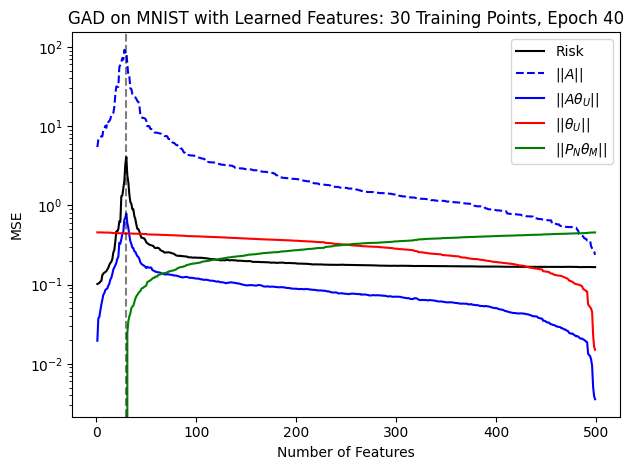

In [249]:
plt.semilogy(np.arange(1, m), risk, label='Risk', color="black")
plt.semilogy(np.arange(1, m), norm_A, label=r"$|| A ||$", color="blue", linestyle='--')
plt.semilogy(np.arange(1, m), norm_A_theta_u, label=r"$|| A \theta_U||$", color="blue")
plt.semilogy(np.arange(1, m), norm_theta_U, label=r"$||\theta_U||$", color="red")
plt.semilogy(np.arange(1, m), norm_PN_theta, label=r"||$P_N \theta_M$||", color="green")

plt.title(f"GAD on MNIST with Learned Features: {N} Training Points, Epoch {epoch_index + 1}")
plt.xlabel("Number of Features")
plt.ylabel("MSE")
plt.axvline([N], color='black', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f'./mnist_plots/LargeModel_GAD_{N}points_epoch{epoch_index}.jpg')
plt.show()